# Chapter 2 — Data and Sampling Distributions

This chapter introduces sampling and the distributions used to understand
how sample statistics vary from one sample to another.

The main ideas are:

- Random sampling and sample bias
- Sample statistics versus population parameters
- Selection bias and regression to the mean
- Sampling distributions
- Central Limit Theorem and standard error
- Bootstrap resampling
- Confidence intervals
- Normal and t-distributions
- Binomial, chi-square, and F-distributions
- Poisson, exponential, and Weibull distributions

The main practical idea is that statistical estimates are based on samples,
so we need to understand how those estimates vary from sample to sample.

## 1. Random Sampling and Sample Bias

A population is the larger set of data that we want to understand, while
a sample is a subset taken from that population.

Random sampling gives each available member of the population an equal
chance of being selected.

Sampling can be performed:

- With replacement: selected observations can be selected again.
- Without replacement: selected observations cannot be selected again.

A representative sample is important because a large but biased sample
can still produce misleading conclusions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Demonstrate random sampling from a simple population.

population = pd.Series(np.arange(1, 101))

sample = population.sample(
    n=10,
    random_state=42
)

sampling_summary = pd.Series({
    'Population size': len(population),
    'Sample size': len(sample),
    'Population mean': population.mean(),
    'Sample mean': sample.mean()
})

display(sampling_summary.to_frame('Value'))

,Value
Population size,100.0
Sample size,10.0
Population mean,50.5
Sample mean,45.6


### Bias

Sampling bias occurs when the sampling procedure systematically produces
a sample that differs from the population of interest.

A random sample can reduce this problem, but random selection alone cannot
fix a poorly defined population or an inappropriate sampling frame.

## 2. Size Versus Quality

A larger dataset is not automatically better.

A smaller, representative sample can be more useful than a huge sample
containing systematic bias or poor-quality observations.

Large datasets are especially valuable when the data is sparse and the
quantity of observations is necessary to capture rare events.

## 3. Sample Mean Versus Population Mean

The mean of a sample is written as x̄, while the population mean is
represented by μ.

The sample mean is an estimate of the population mean:

x̄ = (1 / n) Σ xi

Because a sample contains only part of the population, x̄ will generally
not be exactly equal to μ.

In [2]:
# Compare the mean of a complete population with
# the mean of one randomly selected sample.

population = pd.Series(np.arange(1, 1001))

sample = population.sample(
    n=100,
    random_state=42
)

mean_comparison = pd.Series({
    'Population mean (μ)': population.mean(),
    'Sample mean (x̄)': sample.mean(),
    'Difference': sample.mean() - population.mean()
})

display(mean_comparison.to_frame('Value'))

,Value
Population mean (μ),500.50
Sample mean (x̄),489.78
Difference,-10.72


## 4. Selection Bias and Regression to the Mean

Selection bias occurs when the process used to select observations favors
certain outcomes.

Examples include:

- Nonrandom sampling
- Cherry-picking observations
- Selecting a time period because it produces an interesting result
- Repeatedly testing different models until an interesting result appears

Regression to the mean is the tendency for extreme observations to be
followed by observations that are closer to the average.

This can occur when an observed result is influenced by both persistent
factors and random variation.

In [3]:
# Simulate two measurements of the same subjects.
# The second measurement contains independent random variation.

rng = np.random.default_rng(42)

first_measurement = rng.normal(100, 15, 1000)
second_measurement = (
    100
    + 0.5 * (first_measurement - 100)
    + rng.normal(0, 10, 1000)
)

comparison = pd.DataFrame({
    'First': first_measurement,
    'Second': second_measurement
})

display(comparison.describe().round(2))

,First,Second
count,1000.00,1000.00
mean,99.57,98.97
std,14.84,12.52
min,45.27,59.46
25%,89.56,90.87
50%,100.09,99.19
75%,108.85,107.37
max,147.68,140.71


## 5. Sampling Distribution of a Statistic

A sampling distribution is the distribution of a sample statistic obtained
from many samples drawn from the same population.

This is different from the data distribution:

- Data distribution → distribution of individual observations.
- Sampling distribution → distribution of a statistic calculated from
  many samples.

Sampling distributions allow us to understand how much a statistic can
vary between samples.

In [5]:
# Use loan applicant income data to illustrate sampling distributions.
# The same population is sampled repeatedly with different sample sizes.

loans_income = pd.read_csv('../data/loans_income.csv').squeeze('columns')

sample_means_5 = [
    loans_income.sample(5).mean()
    for _ in range(1000)
]

sample_means_20 = [
    loans_income.sample(20).mean()
    for _ in range(1000)
]

sampling_results = pd.DataFrame({
    'Mean of 5': sample_means_5,
    'Mean of 20': sample_means_20
})

display(sampling_results.describe().round(2))

,Mean of 5,Mean of 20
count,1000.00,1000.00
mean,68517.04,68862.92
std,14603.71,6783.87
min,31540.00,45676.00
25%,58250.00,64215.15
50%,68090.00,68802.52
75%,77608.90,73494.01
max,125600.00,92503.45


## 6. Central Limit Theorem

The Central Limit Theorem states that the distribution of sample means
tends to become approximately normal as the sample size increases, even
when the original population is not normally distributed, provided the
conditions for the approximation are appropriate.

This explains why sampling distributions of means often have a
bell-shaped form.

## Standard Error

The standard error measures the variability of a sample statistic.

For a sample mean:

SE = s / √n

where:

- s = sample standard deviation
- n = sample size

As the sample size increases, the standard error decreases.

In [6]:
# Compare the variability of sample means for two sample sizes.

se_5 = np.std(sample_means_5, ddof=1)
se_20 = np.std(sample_means_20, ddof=1)

standard_error = pd.Series({
    'SE of means (n=5)': se_5,
    'SE of means (n=20)': se_20
})

display(standard_error.to_frame('Standard Error').style.format('{:,.2f}'))

,Standard Error
SE of means (n=5),"14,603.71"
SE of means (n=20),"6,783.87"


## 7. The Bootstrap

The bootstrap estimates the sampling distribution of a statistic by
repeatedly sampling from the observed data **with replacement**.

Basic procedure:

1. Draw a sample with replacement from the observed data.
2. Calculate the statistic.
3. Repeat many times.
4. Examine the resulting distribution.

The bootstrap is useful because it can estimate variability without
requiring a theoretical formula for the sampling distribution.

In [7]:
from sklearn.utils import resample

# Estimate the sampling distribution of the median income
# using bootstrap resampling.

bootstrap_medians = []

for _ in range(1000):
    sample = resample(loans_income)
    bootstrap_medians.append(sample.median())

bootstrap_medians = pd.Series(bootstrap_medians)

bootstrap_summary = pd.Series({
    'Original median': loans_income.median(),
    'Bootstrap mean': bootstrap_medians.mean(),
    'Bootstrap standard error': bootstrap_medians.std()
})

display(
    bootstrap_summary
    .to_frame('Value')
    .style.format('{:,.2f}')
)

,Value
Original median,"62,000.00"
Bootstrap mean,"61,909.78"
Bootstrap standard error,237.80


## 8. Confidence Intervals

A confidence interval provides a range of plausible values for a
population parameter based on a sample.

A confidence level describes the long-run proportion of intervals
constructed using the same procedure that are expected to contain the
parameter.

For example, a 95% confidence interval is constructed so that, over many
repeated samples, approximately 95% of such intervals would contain the
parameter of interest.

In [8]:
# Calculate a percentile-based 95% bootstrap confidence interval.

confidence_interval = np.percentile(
    bootstrap_medians,
    [2.5, 97.5]
)

ci_summary = pd.Series({
    'Estimate': loans_income.median(),
    'Lower 95% bound': confidence_interval[0],
    'Upper 95% bound': confidence_interval[1]
})

display(
    ci_summary
    .to_frame('Value')
    .style.format('${:,.2f}')
)

,Value
Estimate,"$62,000.00"
Lower 95% bound,"$61,000.00"
Upper 95% bound,"$62,000.00"


## 9. Normal Distribution

The normal distribution is a symmetric, bell-shaped distribution
described by its mean and standard deviation.

A standard normal distribution has:

- Mean = 0
- Standard deviation = 1

A z-score standardizes an observation:

z = (x - x̄) / s

The normal distribution is particularly important because many sampling
distributions become approximately normal as sample size increases.

However, the book emphasizes that raw data itself is often not normally
distributed.

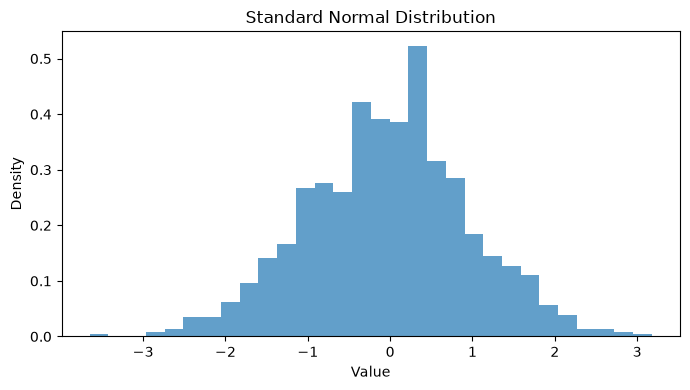

In [9]:
from scipy import stats

# Generate observations from a standard normal distribution.

rng = np.random.default_rng(42)
normal_sample = stats.norm.rvs(size=1000, random_state=rng)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    normal_sample,
    bins=30,
    density=True,
    alpha=0.7
)

ax.set_title('Standard Normal Distribution')
ax.set_xlabel('Value')
ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

## 10. Standard Normal and QQ-Plots

Standardization converts observations to z-scores by subtracting the
mean and dividing by the standard deviation.

A QQ-plot compares the quantiles of observed data with the quantiles of
a theoretical distribution.

If the points approximately follow a straight diagonal line, the sample
is reasonably consistent with the specified distribution.

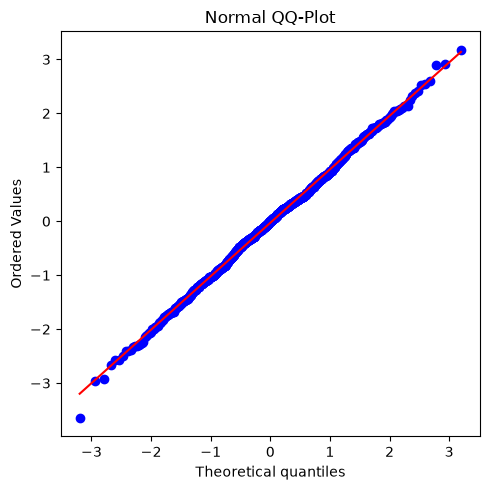

In [10]:
# Compare the sample with a theoretical normal distribution.

fig, ax = plt.subplots(figsize=(5, 5))

stats.probplot(
    normal_sample,
    dist='norm',
    plot=ax
)

ax.set_title('Normal QQ-Plot')

plt.tight_layout()
plt.show()

## 11. Long-Tailed Distributions

A long-tailed distribution contains more extreme observations than would
be expected from a normal distribution.

Assuming that data is normally distributed when it is actually
long-tailed can underestimate the probability of extreme events.

Therefore, the distribution of the actual data should be examined rather
than automatically assuming normality.

## 12. Student's t-Distribution

The t-distribution resembles the normal distribution but has thicker
tails.

It is particularly useful for sample statistics such as means when the
sample size is relatively small.

The shape depends on the degrees of freedom. As the degrees of freedom
increase, the t-distribution becomes increasingly similar to the normal
distribution.

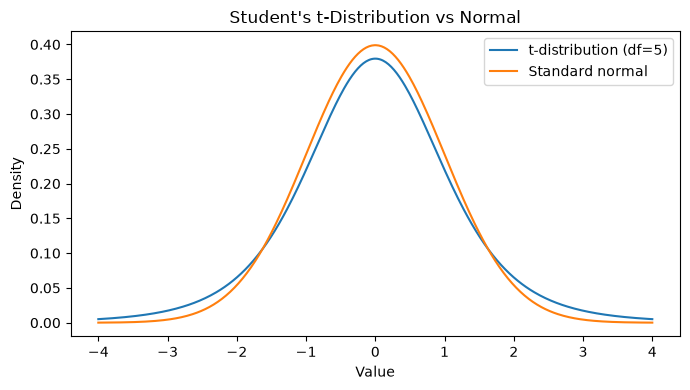

In [11]:
# Compare a t-distribution with 5 degrees of freedom
# to the standard normal distribution.

x = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    x,
    stats.t.pdf(x, df=5),
    label='t-distribution (df=5)'
)

ax.plot(
    x,
    stats.norm.pdf(x),
    label='Standard normal'
)

ax.set_title("Student's t-Distribution vs Normal")
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

## 13. Binomial Distribution

The binomial distribution describes the number of successes in a fixed
number of independent trials when each trial has two possible outcomes.

It is appropriate for situations such as:

- Success/failure
- Buy/don't buy
- Click/don't click
- Fraud/no fraud

The distribution is determined by:

- n = number of trials
- p = probability of success

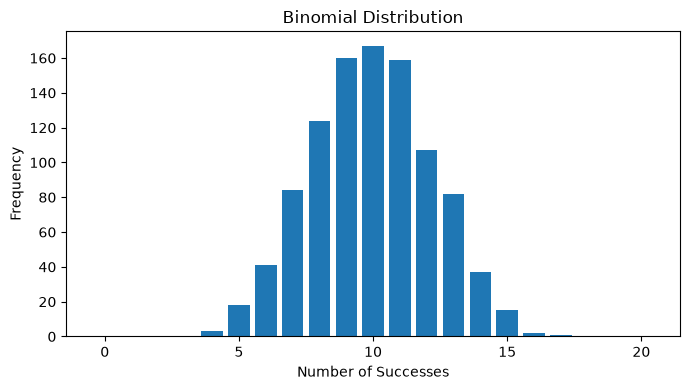

In [12]:
# Simulate the number of successes in 20 trials
# where the probability of success is 0.5.

binomial_sample = stats.binom.rvs(
    n=20,
    p=0.5,
    size=1000,
    random_state=42
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    binomial_sample,
    bins=np.arange(-0.5, 21.5, 1),
    rwidth=0.8
)

ax.set_title('Binomial Distribution')
ax.set_xlabel('Number of Successes')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 14. Chi-Square and F-Distributions

### Chi-Square Distribution

The chi-square distribution is a right-skewed distribution whose shape
depends on its degrees of freedom.

It is used with statistics based on squared deviations and is important
in methods such as chi-square tests.

### F-Distribution

The F-distribution is also determined by degrees of freedom.

It is used when comparing sources of variation, including in analysis of
variance (ANOVA) and regression.

The F-statistic compares variation associated with factors of interest
against residual or within-group variation.

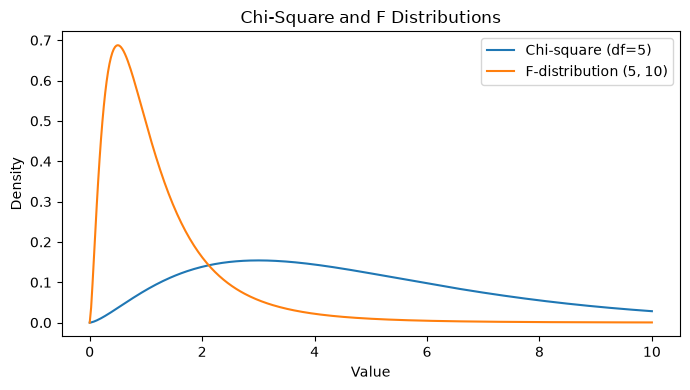

In [13]:
# Visualize the chi-square and F distributions.

x = np.linspace(0, 10, 400)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    x,
    stats.chi2.pdf(x, df=5),
    label='Chi-square (df=5)'
)

ax.plot(
    x,
    stats.f.pdf(x, dfn=5, dfd=10),
    label='F-distribution (5, 10)'
)

ax.set_title('Chi-Square and F Distributions')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

## 15. Poisson and Related Distributions

The Poisson distribution models the number of events occurring in a
specified unit of time or space.

Its main parameter is λ (lambda), the average event rate.

Examples include:

- Website visits per minute
- Customer calls per hour
- Cars arriving at a toll plaza
- Defects per unit of material

The exponential distribution describes the time or distance between
events when the event rate is constant.

The Weibull distribution generalizes the exponential distribution by
allowing the event rate to change over time.

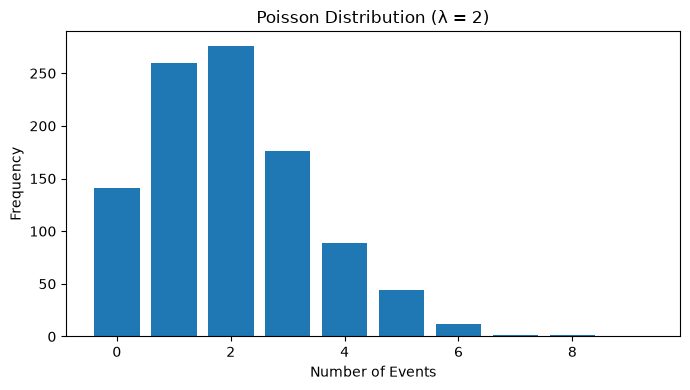

In [14]:
# Simulate event counts using a Poisson distribution.
# Here lambda = 2 events per time period.

poisson_sample = stats.poisson.rvs(
    mu=2,
    size=1000,
    random_state=42
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    poisson_sample,
    bins=np.arange(-0.5, 10.5, 1),
    rwidth=0.8
)

ax.set_title('Poisson Distribution (λ = 2)')
ax.set_xlabel('Number of Events')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

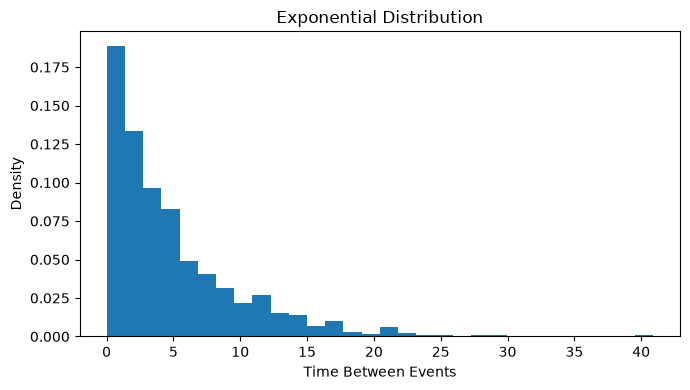

In [15]:
# Simulate the time between events using an exponential distribution.
# A rate of 0.2 events per unit time gives a mean interval of 5 units.

exponential_sample = stats.expon.rvs(
    scale=1 / 0.2,
    size=1000,
    random_state=42
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    exponential_sample,
    bins=30,
    density=True
)

ax.set_title('Exponential Distribution')
ax.set_xlabel('Time Between Events')
ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

### Estimating the Failure Rate

When events are rare, the event rate may be difficult to estimate from
limited observations.

For example, if no failures are observed during a period of operation,
we cannot conclude that the true failure rate is zero. Instead, the
observed data provides information about plausible values of the rate.

## 16. Weibull Distribution

The Weibull distribution is a generalization of the exponential
distribution.

Unlike the exponential distribution, which assumes a constant event
rate, the Weibull distribution can model situations where the event rate
changes over time.

This makes it useful in reliability and failure-time analysis.

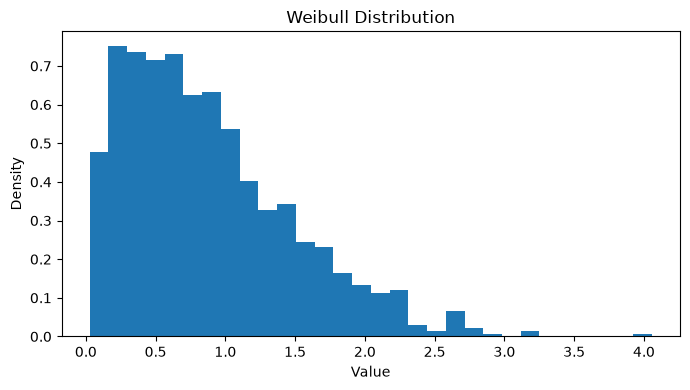

In [16]:
# Generate a sample from a Weibull distribution.

weibull_sample = stats.weibull_min.rvs(
    c=1.5,
    size=1000,
    random_state=42
)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    weibull_sample,
    bins=30,
    density=True
)

ax.set_title('Weibull Distribution')
ax.set_xlabel('Value')
ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

# Chapter 2 Summary

This chapter focused on how samples are obtained and how sample
statistics vary.

The main concepts were:

- Random sampling and sample bias
- Selection bias and regression to the mean
- Sample statistics and population parameters
- Sampling distributions
- Central Limit Theorem
- Standard error
- Bootstrap resampling
- Confidence intervals
- Normal and t-distributions
- Binomial distribution
- Chi-square and F-distributions
- Poisson, exponential, and Weibull distributions

The central idea is that a sample is only one possible realization from a
population. Understanding sampling variability allows us to quantify the
uncertainty associated with estimates and models.

The bootstrap provides a practical way to estimate sampling variability
directly from observed data, while probability distributions provide
theoretical models for different types of processes.